## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


## Dataförståelse & EDA

In [2]:
df = pd.read_csv("data/historical_data.csv")
print(df.shape)
print(df["is_suspicious"].value_counts())

(12000, 18)
is_suspicious
0    10776
1     1224
Name: count, dtype: int64


In [3]:
print(df.isnull().sum())

id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


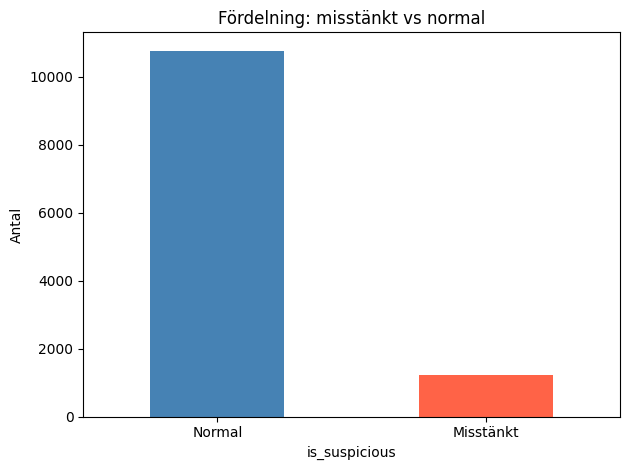

In [4]:
df["is_suspicious"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Fördelning: misstänkt vs normal")
plt.xticks([0,1], ["Normal","Misstänkt"], rotation=0)
plt.ylabel("Antal")
plt.tight_layout()
plt.savefig("figur1_fordelning.png")
plt.show()

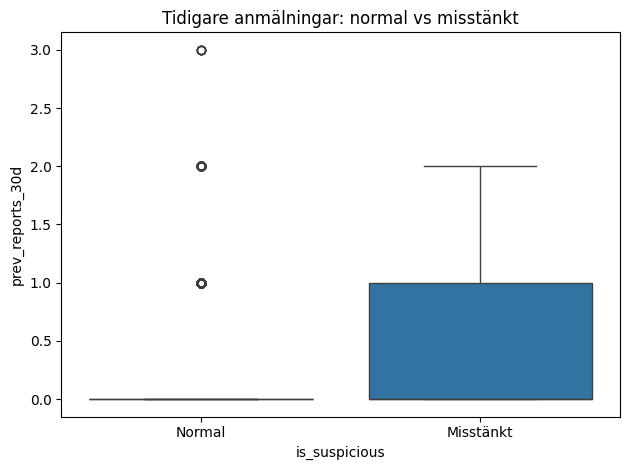

In [5]:
sns.boxplot(x="is_suspicious", y="prev_reports_30d", data=df)
plt.title("Tidigare anmälningar: normal vs misstänkt")
plt.xticks([0,1], ["Normal","Misstänkt"])
plt.tight_layout()
plt.savefig("figur2_anmalningar.png")
plt.show()

## EDA-sammanfattning:
- 12000 rader, 18 kolumner
- 10% misstänkta (1224 av 12000)
- Saknade värden: region (340), price (818), time_to_first_response_min (590)
- Misstänkta konton har tydligt fler tidigare anmälningar än normala konton.

## Train/test + preprocessing

- Vi skapar en train/test-split från historical_data.csv.
- Vi använder stratified split så klasserna fördelas rimligt.
-  Vi bygger pipelines där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).


In [6]:
target_column_name = "is_suspicious"
id_column = "id"
feature_column_names = [col for col in df.columns if col not in [target_column_name, id_column]]

X = df[feature_column_names]
y = df[target_column_name]

categorical_columns = X.select_dtypes(include=["object"]).columns
numeric_columns = X.select_dtypes(exclude=["object"]).columns

print("Kategoriska variabler:", list(categorical_columns))
print("Numeriska variabler:", list(numeric_columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y)

print("\n================================================\n")
print("Datauppdelning:")
print("Träningsdata:", X_train.shape, y_train.shape)
print("Testdata:", X_test.shape, y_test.shape)  
print("\n================================================\n")
print("Träningsdata - klassfördelning:")
print(y_train.value_counts(normalize=True))
print("\nTestdata - klassfördelning:")
print(y_test.value_counts(normalize=True))


Kategoriska variabler: ['event_type', 'category', 'region', 'device']
Numeriska variabler: ['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']


Datauppdelning:
Träningsdata: (9600, 16) (9600,)
Testdata: (2400, 16) (2400,)


Träningsdata - klassfördelning:
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64

Testdata - klassfördelning:
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

rdf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1))
])

pipelines = {
    "Logistic Regression": logreg_pipeline, 
    "Decision Tree": tree_pipeline,
    "Random Forest": rdf_pipeline
}

## Modellering och jämförelse

- Baseline: Logistic Regression
- Ytterligare modeller: Decision Tree och Random Forest
- Utvärdering: vi använder cross-validation på träningsdatan.
- Metric: ROC-AUC
- Motivering: vår stakeholder (Security Analyst) vill ha en modell som generaliserar bra till ny data. ROC-AUC mäter hur bra modellen kan rangordna misstänkta händelser utan att bero på ett specifikt threshold. Det gör metricen mer robust om beteenden förändras över tid.

In [8]:
metric = "roc_auc"

print("\n================================================\n")
print("Cross-validation (5 folds)")
print("Metric:", metric)

results = []

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=metric,
        n_jobs=-1
    )

    mean_score = scores.mean()
    std_score = scores.std()

    print("\n----------------------------------")
    print(name)
    print("Scores:", np.round(scores, 3))
    print("Mean ROC-AUC:", round(mean_score, 3))
    print("Std:", round(std_score, 3))

    results.append({
        "model": name,
        "mean_auc": mean_score
    })



Cross-validation (5 folds)
Metric: roc_auc

----------------------------------
Logistic Regression
Scores: [0.749 0.718 0.733 0.76  0.738]
Mean ROC-AUC: 0.74
Std: 0.014

----------------------------------
Decision Tree
Scores: [0.578 0.575 0.527 0.545 0.565]
Mean ROC-AUC: 0.558
Std: 0.019

----------------------------------
Random Forest
Scores: [0.737 0.729 0.743 0.735 0.733]
Mean ROC-AUC: 0.735
Std: 0.005


In [9]:
results_df = pd.DataFrame(results)

print("\n================================================\n")
print("Modelljämförelse")

results_df.sort_values("mean_auc", ascending=False)



Modelljämförelse


,model,mean_auc
0,Logistic Regression,0.739702
2,Random Forest,0.735337
1,Decision Tree,0.558202


## Modellering och jämförelse - sammanfattning:

- Vi jämför tre modeller: Logistic Regression, Decision Tree och Random Forest.
- Cross-validation (5 folds) används för att utvärdera modellerna med metric ROC-AUC.
- Resultaten visar att Logistic Regression presterar bäst, tätt följd av Random Forest, medan Decision Tree presterar betydligt sämre.
- Vi väljer därför Logistic Regression som slutlig modell eftersom den ger högst genomsnittlig ROC-AUC.
- En enklare modell kan också vara mer stabil över tid, vilket är viktigt eftersom beteenden i systemet kan förändras och modellen behöver generalisera till nya typer av aktivitet.

In [10]:
chosen_model_name = "Logistic Regression"
print("Tuning:", chosen_model_name)

param_grid = [
     # L2 (Ridge)
    {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__solver": ["lbfgs"],
        "model__l1_ratio": [0]
    },
    # L1 (Lasso)
    {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__solver": ["saga"],
        "model__l1_ratio": [1]
    }
]

grid = GridSearchCV(
    estimator=pipelines[chosen_model_name],
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameter:", grid.best_params_)
print("Best roc/auc  :", grid.best_score_)

Tuning: Logistic Regression
Best parameter: {'model__C': 0.1, 'model__l1_ratio': 1, 'model__solver': 'saga'}
Best roc/auc  : 0.7414025117369889


## Optimering av Logistic Regression

Vi körde GridSearchCV på träningsdatan med 5-fold cross-validation och ROC-AUC som mätvärde.
Vi testade olika C(0.01 upp till 100) för att se hur mycket regularisering som passade bäst, samt Ridge vs Lasso.

Bäst blev:
- C = 0.1, l1_ratio = 1, solver = saga med ROC-AUC på 0.7414~
- Marginellt bättre än lbfgs med ett ROC-AUC värde på 0.7394~

Optimeringen gav bara en liten förbättring eftersom modellen redan var nära sitt tak, så mer tuning ger begränsad effekt.

## Threshold / Prioritering

(Prioritering "Top-X" vald)

Istället för en fast threshold använder vi Top-X prioritering:
modellen rankar alla transaktioner efter misstänksamhet och analytikern
granskar alltid exakt de X mest riskfyllda — varje dag, oavsett hur
modellens sannolikheter förändras.

**Varför inte threshold?**
Med fast gräns, att "flagga allt över 35%" kan leda till oförutsägbar arbetsbelastning —
om modellen försämras lite, kan den flagga 0 eller 5000 transaktioner.
Top-X ger alltid samma antal: stabilt och robust.

**Varför 50?**
En realistisk daglig granskningsmängd för en analytiker.
Värdet kan justeras sedan direkt via variabeln TOP_X.

In [11]:
# Använder den tunade modellen från GridSearchCV som slut-modell
best_model = grid.best_estimator_
# Hämtar sannolikheter för testdata
y_proba = best_model.predict_proba(X_test)[:, 1]
print("Probabilities ready. Shape:", y_proba.shape)

Probabilities ready. Shape: (2400,)


In [12]:
# Sätter antal transaktioner att flagga per dag
TOP_X = 50

# Gör en ranking på testdata, sort efter sannolikhet — "högst misstänkt" först
ranked_indices = np.argsort(y_proba)[::-1]

# Tar de TOP_X mest misstänkta
top_x_indices = ranked_indices[:TOP_X]
top_x_proba   = y_proba[top_x_indices]
top_x_true    = y_test.iloc[top_x_indices]

# Vill nu ta fram hur många av de TOP_X är faktiskt misstänkta?
hits = top_x_true.sum()
precision_topx = hits / TOP_X

print(f"Top-{TOP_X} mest misstänkta transaktioner:")
print(f"  Faktiskt misstänkta (träff): {int(hits)}/{TOP_X}")
print(f"  Antal rätt av flaggade:      {precision_topx:.2%}")


Top-50 mest misstänkta transaktioner:
  Faktiskt misstänkta (träff): 21/50
  Antal rätt av flaggade:      42.00%


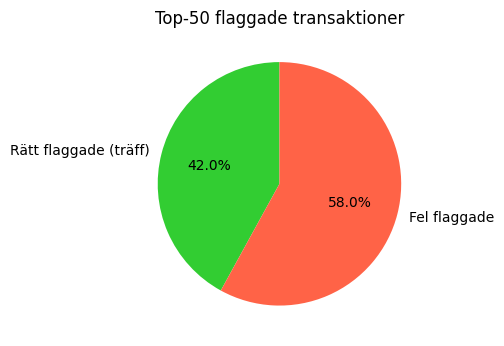

In [13]:
# Visualiserar antalet rätt flaggade i Top-X
labels = ["Rätt flaggade (träff)", "Fel flaggade"]
sizes  = [int(hits), TOP_X - int(hits)]
colors = ["limegreen", "tomato"]

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors,
        autopct="%1.1f%%", startangle=90)
plt.title(f"Top-{TOP_X} flaggade transaktioner")
plt.tight_layout()
plt.savefig("figur3_topx.png", dpi=150)
plt.show()


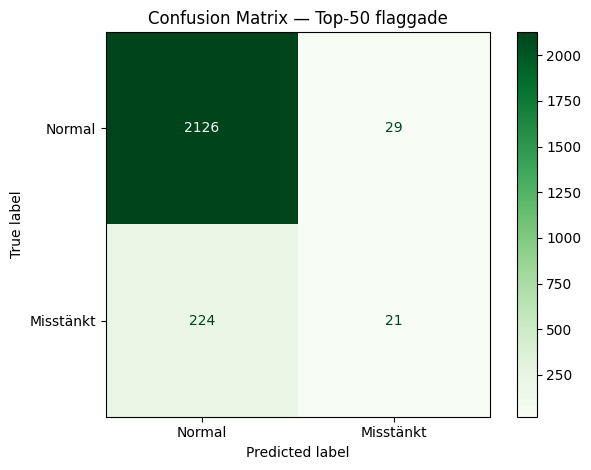

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Vi gör om Top-X ranking till binära prediktioner inför confusion matrix
y_pred_topx = np.zeros(len(y_test), dtype=int)
y_pred_topx[top_x_indices] = 1

# Nu visar confusion matrix
cm = confusion_matrix(y_test, y_pred_topx)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Misstänkt"])
disp.plot(cmap="Greens")
plt.title(f"Confusion Matrix — Top-{TOP_X} flaggade")
plt.tight_layout()
plt.savefig("figur4_confusion_matrix.png", dpi=150)
plt.show()


### Sammanfattning: Threshold / Prioritering

- Vi använder **Top-50 prioritering** istället för en fast threshold.
- Modellen rankar alla transaktioner efter misstänksamhet — analytikern granskar alltid exakt 50 per dag.
- Av de 50 flaggade var **21 faktiskt misstänkta** (42% träff-ratio — 4x bättre än slumpen).
- Strategin är robust mot modell-drift: arbetsbördan förblir stabil även om modellens sannolikheter förändras.


## Deploy-test: ny data

Ny data shape: (2000, 17)

Median jämförelse mellan training data och new data
                            Training_median  New_data_median  Difference
day                                    7.00             3.00       -4.00
account_age_days                      66.30            52.25      -14.05
num_prev_listings                      3.00             3.00        0.00
prev_reports_30d                       0.00             0.00        0.00
verification_level                     1.00             1.00        0.00
price                                148.21           148.17       -0.04
num_images                             3.00             3.00        0.00
message_length                       107.00           107.00        0.00
contains_off_platform                  0.00             0.00        0.00
urgency_words                          0.00             0.00        0.00
payment_attempt                        0.00             0.00        0.00
time_to_first_response_min            13.50  

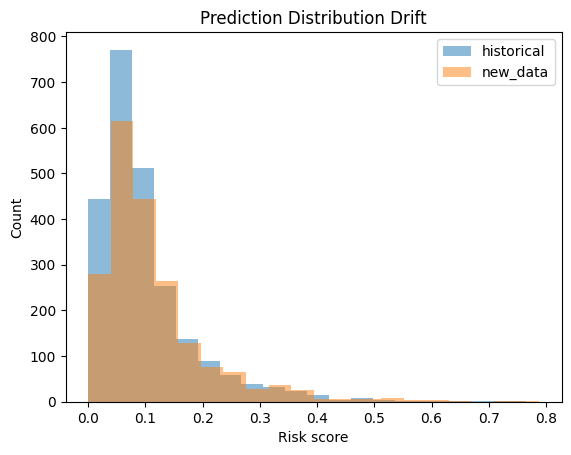


Top-X mest misstänkta:
          risk
1092  0.787976
1398  0.729033
1547  0.660330
1130  0.642330
1831  0.612847
1538  0.596422
486   0.593127
124   0.591191
751   0.565878
792   0.563716


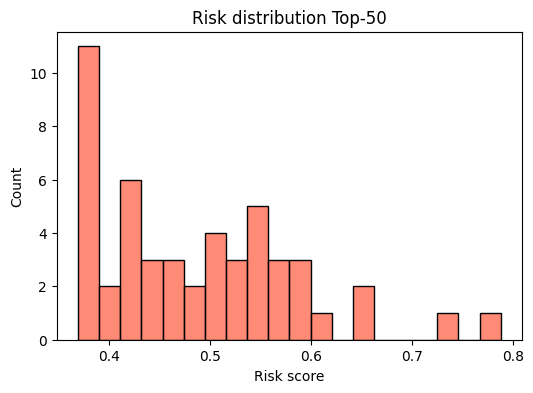

In [15]:
#Ladda ny data
new_df = pd.read_csv("data/new_data.csv")

print("Ny data shape:", new_df.shape)

# Säkerställ exakt samma features som modellen tränades på
new_df = new_df.reindex(columns=X.columns)

# Jämföra medianer av numeriska kolumner
numeric_cols = new_df.select_dtypes(include=np.number).columns

medians_comparison = pd.DataFrame({
    "Training_median": X_train[numeric_cols].median(),
    "New_data_median": new_df[numeric_cols].median()
})

medians_comparison["Difference"] = medians_comparison["New_data_median"] - medians_comparison["Training_median"]

print("\nMedian jämförelse mellan training data och new data")
print(medians_comparison)

#Köra modellen
risk_scores = best_model.predict_proba(new_df)[:, 1]

# Lägg till risk i dataframe
new_df["risk"] = risk_scores

print("\nExempel på riskscore:")
print(new_df[["risk"]].head())

# Distributions Test

old_proba = best_model.predict_proba(X_test)[:, 1]
new_proba = new_df["risk"]

plt.hist(old_proba, bins=20, alpha=0.5, label="historical")
plt.hist(new_proba, bins=20, alpha=0.5, label="new_data")
plt.legend()
plt.title("Prediction Distribution Drift")
plt.xlabel("Risk score")
plt.ylabel("Count")
plt.savefig("figur5_Predictiondrift.png")
plt.show()

# Top X lista (10 utav 50 visas)

TOP_X = 50
priority_list = new_df.sort_values("risk", ascending=False).head(TOP_X)

print("\nTop-X mest misstänkta:")
print(priority_list[["risk"]].head(10))

#Fördelning Top X

plt.figure(figsize=(6,4))
sns.histplot(priority_list["risk"], bins=20, color="tomato")

plt.title(f"Risk distribution Top-{TOP_X}")
plt.xlabel("Risk score")
plt.ylabel("Count")
plt.savefig("figur6_RiskDistribution.png")
plt.show()

## Sammanfattning deploy test

New Data har någorlunda samma distribution som den historiska datan dvs ingen märkbar drift.   
30 utav 50 har en risk-score under 0,5. Beroende på hur arbetsbelastningen ser ut och hur mycket tid man har för att gå igenom de flaggade annonserna så kan siffran för Top X justeras efter behov.